# LOAD LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import json
from datetime import datetime
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import load_parquet
import os
import sys
# Custom utilities
# Add the parent directory (project root) to sys.path
# "Go up two levels" and add to path
sys.path.append(os.path.abspath('../../../')) 
from src.config import PERIOD_START, PERIOD_END, select_period
from src.gapfilling_utils import (
    setup_log_transform,
    undersample_target,
    learn_gap_dist,
    create_artificial_gap_splits,
    plot_cv_splits
)

# CONFIGURATION

In [2]:
START_DATE, END_DATE = PERIOD_START, PERIOD_END  # dataset period, see src/config.py
TARGET_FLUX = 'FN2O'
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
N_FOLDS = 10
PARCEL_CERTAIN = True # choose if to use in the training also values coming from mixed contribution
LOG_TRANSFORM = False
UNDERSAMPLE = False
ADD_TRT = True

# LOAD DATA

In [3]:
data_main = fluxes = load_parquet(filepath=r"82.1.1_GapFillingDataset.parquet")
data_main = select_period(data_main, timestamp='middle')
print(f"\nUsing data from {START_DATE} to {END_DATE}")
TARGET = f"{TARGET_FLUX}_L3.3_CUT_50_QCF0"
print(f"\nTarget column: {TARGET}")

data_main

Loaded .parquet file 82.1.1_GapFillingDataset.parquet (0.327 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
select_period: kept 14928 of 14928 records (2023-10-17 00:15:00 to 2024-08-22 23:45:00, timestamp=middle)

Using data from 2023-10-17 00:00:00 to 2024-08-23 00:00:00

Target column: FN2O_L3.3_CUT_50_QCF0


,NEE_L3.3_CUT_50_QCF_footprint_gfXGBoost,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,FN2O_L3.3_CUT_16_QCF,FN2O_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_84_QCF,FN2O_L3.3_CUT_16_QCF0,FN2O_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FN2O_RANDUNC_HF,SW_IN_POT,prec,ta,...,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,can_height,cropN,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-17 00:15:00,5.957099,-4.642565,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.966667,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,NaN,NaN,0
2023-10-17 00:45:00,5.957099,-4.642565,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.966667,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,NaN,NaN,1
2023-10-17 01:15:00,5.957099,-4.676087,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.566667,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,NaN,NaN,2
2023-10-17 01:45:00,5.957099,-4.701027,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.266667,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,NaN,NaN,3
2023-10-17 02:15:00,5.957099,-4.689964,NaN,NaN,NaN,NaN,NaN,NaN,None,uncertain,0.5,NaN,NaN,0.0,1.400000,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.0,30.0,30.0,30.0,NaN,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 21:45:00,5.789159,-1.174224,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,0.246469,0.0,0.0,15.870000,...,-1.456268,-0.031887,-0.371716,-0.464268,184.456349,187.286349,174.585550,12.443672,188.0,1.0,30.0,1.0,0.0,0.0,14923
2024-08-22 22:15:00,5.719062,-1.229992,2.623038,2.623038,NaN,NaN,NaN,NaN,B,certain,1.0,0.636039,0.0,0.0,15.160000,...,-1.399429,-0.000719,-0.361714,-0.454507,184.269841,187.279204,173.906660,14.317380,188.0,1.0,30.0,1.0,0.0,0.0,14924
2024-08-22 22:45:00,5.507258,-1.028798,1.743544,1.743544,1.743544,NaN,NaN,NaN,B,certain,1.0,0.343247,0.0,0.0,15.100000,...,-1.435013,0.009201,-0.350463,-0.453738,184.083333,187.271988,173.230410,16.309472,188.0,1.0,30.0,1.0,0.0,0.0,14925


# CLEAN DATA

In [4]:
# Remove NAs
data = data_main[data_main[TARGET].notna()].copy()

# Remove data with mixed attribution if PARCEL_CERTAIN==True
if PARCEL_CERTAIN:
    before = len(data)
    data = data.loc[data["parcel_certainty"].eq("certain")].copy()
    print(f"Filtered parcel_certainty=='certain': {len(data)}/{before} rows kept")
else:
    print("Using all data regardless of parcel_certainty (mixed contribution allowed)")

data

Filtered parcel_certainty=='certain': 4882/5532 rows kept


,NEE_L3.3_CUT_50_QCF_footprint_gfXGBoost,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,FN2O_L3.3_CUT_16_QCF,FN2O_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_84_QCF,FN2O_L3.3_CUT_16_QCF0,FN2O_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FN2O_RANDUNC_HF,SW_IN_POT,prec,ta,...,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,can_height,cropN,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-07 16:15:00,1.440639,-0.121658,0.324973,0.324973,0.324973,0.324973,0.324973,0.324973,B,certain,1.0,0.124789,168.35800,0.0,7.300000,...,0.022161,0.321719,0.557017,0.072530,0.000000,0.000000,2.274546,1.037818,29.0,22.0,30.0,22.0,0.188641,5.153570,1040
2023-11-07 17:15:00,2.060704,-0.782134,0.339963,0.339963,0.339963,0.339963,0.339963,0.339963,B,certain,1.0,0.264532,3.38364,0.5,6.600000,...,0.029544,0.798931,0.793294,0.894488,0.000000,0.000000,2.263177,1.031258,29.0,22.0,30.0,22.0,0.189415,5.154212,1042
2023-11-07 17:45:00,1.999698,-0.715234,-0.983566,-0.983566,-0.983566,-0.983566,-0.983566,-0.983566,B,certain,1.0,0.344428,0.00000,0.2,6.633333,...,0.435220,0.764205,0.910265,0.877980,0.000000,0.000000,2.257514,1.027996,29.0,22.0,30.0,22.0,0.189803,5.154534,1043
2023-11-07 18:15:00,1.908674,-0.638819,-0.064456,-0.064456,-0.064456,-0.064456,-0.064456,-0.064456,B,certain,1.0,0.172716,0.00000,0.5,6.366667,...,0.327660,0.897999,1.085670,1.031942,0.000000,0.000000,2.251865,1.024747,29.0,22.0,30.0,22.0,0.190191,5.154856,1044
2023-11-07 18:45:00,1.949714,-0.687676,0.066895,0.066895,0.066895,0.066895,0.066895,0.066895,B,certain,1.0,0.166231,0.00000,0.0,6.200000,...,0.383403,0.812505,0.958576,1.030199,0.000000,0.000000,2.246230,1.021509,29.0,22.0,30.0,22.0,0.190579,5.155178,1045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 14:45:00,7.660107,-1.738305,0.562096,0.562096,0.562096,0.562096,0.562096,0.562096,A,certain,0.0,0.448610,905.83500,0.0,23.103333,...,-1.428149,-0.217355,-0.290252,-0.397630,187.067460,187.379274,184.373050,0.120233,188.0,1.0,30.0,1.0,0.000000,0.000000,14909
2024-08-22 15:15:00,12.252563,-6.109375,1.825937,1.825937,1.825937,1.825937,1.825937,1.825937,B,certain,1.0,0.298728,829.23800,0.0,24.313333,...,-1.494919,-0.272192,-0.318445,-0.411587,186.880952,187.373056,183.656100,0.247123,188.0,1.0,30.0,1.0,0.000000,0.000000,14910
2024-08-22 15:45:00,8.197114,-2.013018,1.238879,1.238879,1.238879,1.238879,1.238879,1.238879,B,certain,1.0,0.205148,741.89500,0.0,24.536667,...,-1.467906,-0.339830,-0.338404,-0.407802,186.694444,187.366777,182.941939,0.447626,188.0,1.0,30.0,1.0,0.000000,0.000000,14911


# SELECT FEATURES

In [5]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# If ADD_TRT is True we add the trt variable even if it was not in the best feature set
if ADD_TRT:
    if 'trt' not in selected_features:
        selected_features.append('trt')
    print('\nThe treatment variable (trt) is included in the feature set')
else:
    if 'trt' in selected_features:
        selected_features.remove('trt')
    print('\nThe treatment variable (trt) is not included in the feature set')

# Drop NAs and keep only selected features
train_mask = data[TARGET].notna() & data[selected_features].notna().all(axis=1)
df_train = data.loc[train_mask, selected_features + [TARGET]].copy()
print(f"\nTraining rows (complete-case): {len(df_train)}/{len(data)}")

X = df_train[selected_features]
y = df_train[TARGET].astype(float)

df_train


The treatment variable (trt) is included in the feature set

Training rows (complete-case): 4882/4882


,GPP_NT_CUT_50_QCF_footprint_gfXGBoost,ta,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,prec_lag6h,ta_lag6h,ts_0.15_gfXG_lag3h,ts_0.3_gfXG_lag6h,...,wfps_0.05_gfXG_diff12h,wfps_0.05_gfXG_diff24h,wfps_0.15_gfXG_diff6h,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,id,trt,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-07 16:15:00,-0.121658,7.300000,6.462361,6.317266,3.975786,49.439283,55.991355,43.420677,21.0,60.0,21.0,0.0,9.233333,4.473006,4.258139,...,-0.255747,1.173655,-0.107292,0.179404,0.022161,0.072530,0.000000,0.000000,2.274546,1.037818,29.0,22.0,1040,1.0,0.324973
2023-11-07 17:15:00,-0.782134,6.600000,5.326865,6.262608,3.980413,49.767772,55.745995,44.111634,21.0,60.0,21.0,0.0,9.666667,4.617176,4.235539,...,-0.018966,1.664353,-0.326167,-0.081217,0.029544,0.894488,0.000000,0.000000,2.263177,1.031258,29.0,22.0,1042,1.0,0.339963
2023-11-07 17:45:00,-0.715234,6.633333,5.533361,6.286528,3.958010,49.930323,56.041919,44.126805,21.0,60.0,21.0,0.0,9.666667,5.605748,4.400391,...,0.231753,1.895529,-0.050753,0.200712,0.435220,0.877980,0.000000,0.000000,2.257514,1.027996,29.0,22.0,1043,1.0,-0.983566
2023-11-07 18:15:00,-0.638819,6.366667,5.339899,6.178624,4.041503,50.516978,55.922282,44.267403,21.0,60.0,21.0,0.0,10.000000,5.790372,3.932901,...,0.836835,2.607345,-0.171272,0.131912,0.327660,1.031942,0.000000,0.000000,2.251865,1.024747,29.0,22.0,1044,1.0,-0.064456
2023-11-07 18:45:00,-0.687676,6.200000,4.608193,6.178475,4.059805,49.042598,55.987696,44.173501,21.0,60.0,21.0,0.0,10.033333,5.873338,4.011118,...,-0.724384,1.062721,-0.051640,0.140143,0.383403,1.030199,0.000000,0.000000,2.246230,1.021509,29.0,22.0,1045,1.0,0.066895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 14:45:00,-1.738305,23.103333,23.721111,20.372222,19.119630,26.772063,43.804128,42.169136,1.0,29.0,60.0,0.0,15.420000,18.781852,19.200000,...,-1.441244,-3.937213,-0.601154,-0.871593,-1.428149,-0.397630,187.067460,187.379274,184.373050,0.120233,188.0,1.0,14909,0.0,0.562096
2024-08-22 15:15:00,-6.109375,24.313333,24.163704,20.632593,19.200000,26.544859,43.719702,42.136662,1.0,29.0,60.0,0.0,16.026667,18.973704,19.147037,...,-1.590694,-3.982961,-0.650100,-0.909366,-1.494919,-0.411587,186.880952,187.373056,183.656100,0.247123,188.0,1.0,14910,1.0,1.825937
2024-08-22 15:45:00,-2.013018,24.536667,24.436665,20.870000,19.238148,26.318742,43.678179,42.112901,1.0,29.0,60.0,0.0,16.613333,19.169259,19.100000,...,-1.752639,-4.001665,-0.582462,-0.936038,-1.467906,-0.407802,186.694444,187.366777,182.941939,0.447626,188.0,1.0,14911,1.0,1.238879


# IMBALANCE HANDLING

## UNDER SAMPLING

In [6]:
if UNDERSAMPLE:
    df_train2, cutoff_value = undersample_target(
        df_train, TARGET,
        quantile_cutoff=0.8,
        fraction=0.5,
        random_state=42,
        verbose=True,
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
else:
    print("Undersampling not applied.")

Undersampling not applied.


## LOG TRANSFORMATION

In [7]:
if LOG_TRANSFORM:
    log_fn, inv_fn, min_value, df_train2 = setup_log_transform(
        df_train, TARGET, apply=True, plot=True, bins=20
    )
    df_train = df_train2
    X = df_train.drop(columns=[TARGET])
    y = df_train[TARGET].astype(float)
    print(f"Applied log1p transform (shift={min_value if min_value < 0 else 0.0:.4g}).")
else:
    inv_fn = None
    print("Log transform not applied.")

Log transform not applied.


# CROSS-VAL SPLITS

  Gap distribution: fitted mixture (cvm distance 18.8343; raw baseline 22.8937)
CV Strategy: artificial gaps in real time; 10 splits; test fractions 0.095-0.103
  Coverage: 1689/4882 rows never held out (34.6%); mean times held out 1.00


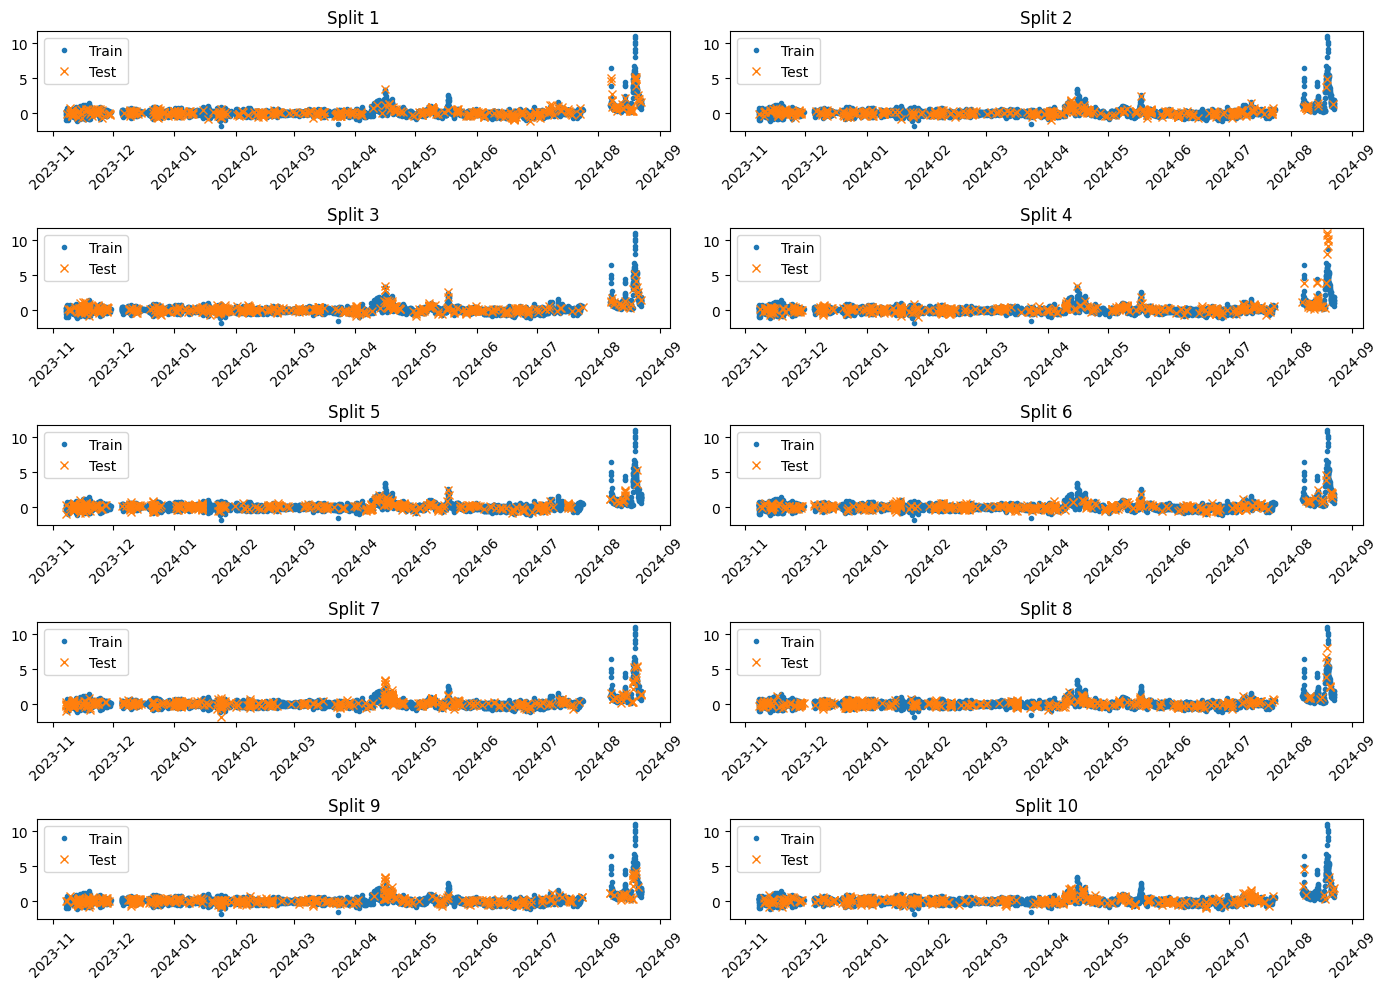

In [8]:
# Artificial-gap CV splits (Irvin et al. 2021 style)
rng = np.random.default_rng(42)

sampling_pmf = learn_gap_dist(data_main[TARGET], n_grid=6, n_mc=20, rng=rng, verbose=True)

splits, coverage = create_artificial_gap_splits(
    target_full=data_main[TARGET],   # full series, real NaNs intact -- NOT X/y
    train_index=X.index,
    sampling_pmf=sampling_pmf,
    n_splits=N_FOLDS,
    eval_frac=0.1,
    rng=rng,
    verbose=True,
)

# optional diagnostic plot
plot_cv_splits(X, y, splits, ncols=2);


# HYPERPARAMETER TUNING

In [9]:
# DEFINE RANGES
if MODEL_TYPE == 'XGBoost':
    # XGBoost: Use continuous distributions for fine-tuning
    PARAM_DIST = {
        'n_estimators': randint(100, 1000),      # Any integer 100-1000
        'max_depth': randint(3, 15),             # Any integer 3-15
        'learning_rate': uniform(0.005, 0.1),    # Any float 0.005-0.105
        'subsample': uniform(0.6, 0.4),          # 0.6 to 1.0
        'colsample_bytree': uniform(0.6, 0.4),   # 0.6 to 1.0
        'min_child_weight': randint(1, 10),
        'gamma': uniform(0, 0.5)
    }
    model = XGBRegressor(n_jobs=-1, random_state=42)

elif MODEL_TYPE == 'RandomForest':
    # RF: Integers for counts/depths
    PARAM_DIST = {
        'n_estimators': randint(100, 500),
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'max_features': ['sqrt', 'log2', 1.0]
    }
    model = RandomForestRegressor(n_jobs=-1, random_state=42)

# RUN RANDOM SEARCH
print(f"Starting optimization for {MODEL_TYPE}...")

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=PARAM_DIST,
    n_iter=100,      # number of random tries
    cv=splits,       # list of (train_idx, test_idx) 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

search.fit(X, y)

# RESULTS
print(f"Best RMSE: {-search.best_score_:.4f}")
print("Best Params:", search.best_params_)

Starting optimization for XGBoost...
Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Best RMSE: 0.3127
Best Params: {'colsample_bytree': np.float64(0.7380330511289547), 'gamma': np.float64(0.17380960724134176), 'learning_rate': np.float64(0.008180468148516513), 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 744, 'subsample': np.float64(0.7843115072130903)}


# EXPORT 

In [10]:
filename = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(filename, "w") as f:
    json.dump(search.best_params_, f)

# **End of notebook**

In [11]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2026-09-22 18:22:09
